### Supress Warnings

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

***

In [4]:
df_2 = pd.read_csv(
    'coffee_shop_transactions_cleaned.csv',
    parse_dates = ['DateTime']   # parse_dates → converts the column to datetime64 on load
                                 # without this, DateTime loads as plain text (string)
                                 # and .dt.date / .dt.hour will throw AttributeError
)

print('\n Number of Rows,Cols : ', df_2.shape)
print('\n DateTime dtype      :', df_2['DateTime'].dtype)  # should be datetime64[ns]

df_2


 Number of Rows,Cols :  (21, 7)

 DateTime dtype      : datetime64[ns]


,TransactionID,DateTime,Item,PricePerItem,Quantity,TotalPrice,PaymentMethod
0,TX1001,2025-09-08 08:15:23,Cappuccino,4.2,1,4.2,Credit Card
1,TX1002,2025-09-01 08:22:11,Latte,4.8,2,9.6,Cash
2,TX1003,2025-09-12 08:35:46,Espresso,3.3,1,3.3,Mobile Pay
3,TX1004,2025-09-03 08:50:39,Croissant,3.0,1,3.0,Credit Card
4,TX1006,2025-09-02 09:05:55,Mocha,5.1,1,5.1,Mobile Pay
5,TX1007,2025-09-15 09:15:08,Tea,2.7,1,2.7,Credit Card
6,TX1008,2025-09-05 09:30:42,Latte,4.8,1,4.8,Mobile Pay
7,TX1009,2025-09-04 09:45:14,Bagel,3.3,1,3.3,Cash
8,TX1010,2025-09-10 10:00:27,Cappuccino,4.2,2,8.4,Credit Card
9,TX1011,2025-09-18 10:15:50,Espresso,3.3,1,3.3,Cash


***

## 📊 Section 3 — Exploratory Data Analysis (EDA)

| # | Analysis | Pandas / Matplotlib method used |
|---|---|---|
| 1 | Statistical snapshot | `.describe()`, `.nunique()`, `.sum()` |
| 2 | Items ordered | `value_counts()` → bar chart |
| 3 | Revenue by item | `groupby` + `sum()` → horizontal bar |
| 4 | Payment method | `value_counts()` → pie + bar |
| 5 | Daily revenue trend | `.dt.date` + `groupby` → line chart |
| 6 | Hourly sales pattern | `.dt.hour` + `groupby` → bar chart |
| 7 | Order value distribution | `.hist()` + box plot |
| 8 | Quantity per item | `groupby` + `agg` → grouped bar |
| 9 | Correlation heatmap | `.corr()` + `matshow` |
| 10 | Key insights summary | Computed metrics |


### 1️⃣ Statistical Snapshot of Cleaned Data
> Before plotting anything, always confirm what the clean dataset looks like numerically.
> `describe()` gives count, mean, std, min, quartiles and max for every numeric column.

In [5]:
# Full numeric summary of the cleaned df_2
print('Shape of cleaned dataset:', df_2.shape)
print()
print('--- Numeric Summary ---')
print(df_2[['PricePerItem','Quantity','TotalPrice']].describe().round(2))
print()
print('--- Quick Business Numbers ---')
print(f'  Unique items       : {df_2["Item"].nunique()} → {sorted(df_2["Item"].unique())}')
print(f'  Payment methods    : {sorted(df_2["PaymentMethod"].unique())}')
print(f'  Total revenue      : ${df_2["TotalPrice"].sum():.2f}')
print(f'  Average order value: ${df_2["TotalPrice"].mean():.2f}')
print(f'  Max single order   : ${df_2["TotalPrice"].max():.2f}')
print(f'  Min single order   : ${df_2["TotalPrice"].min():.2f}')
print(f'  Date range         : {df_2["DateTime"].min().date()} → {df_2["DateTime"].max().date()}')

Shape of cleaned dataset: (21, 7)

--- Numeric Summary ---
       PricePerItem  Quantity  TotalPrice
count         21.00     21.00       21.00
mean           3.93      1.24        5.03
std            0.83      0.44        2.54
min            2.70      1.00        2.70
25%            3.30      1.00        3.30
50%            4.20      1.00        4.20
75%            4.80      1.00        5.10
max            5.10      2.00       10.20

--- Quick Business Numbers ---
  Unique items       : 9 → ['Americano', 'Bagel', 'Cappuccino', 'Croissant', 'Espresso', 'Latte', 'Mocha', 'Muffin', 'Tea']
  Payment methods    : ['Cash', 'Credit Card', 'Mobile Pay']
  Total revenue      : $105.60
  Average order value: $5.03
  Max single order   : $10.20
  Min single order   : $2.70
  Date range         : 2025-09-01 → 2025-09-26


### 2️⃣ How Many Times Was Each Item Ordered?
> `value_counts()` counts how often each item appears across all transactions.  
> This tells us **popularity** — not revenue.

Order frequency per item:
 Item
Latte         5
Cappuccino    4
Espresso      3
Croissant     2
Mocha         2
Tea           2
Bagel         1
Americano     1
Muffin        1
Name: count, dtype: int64


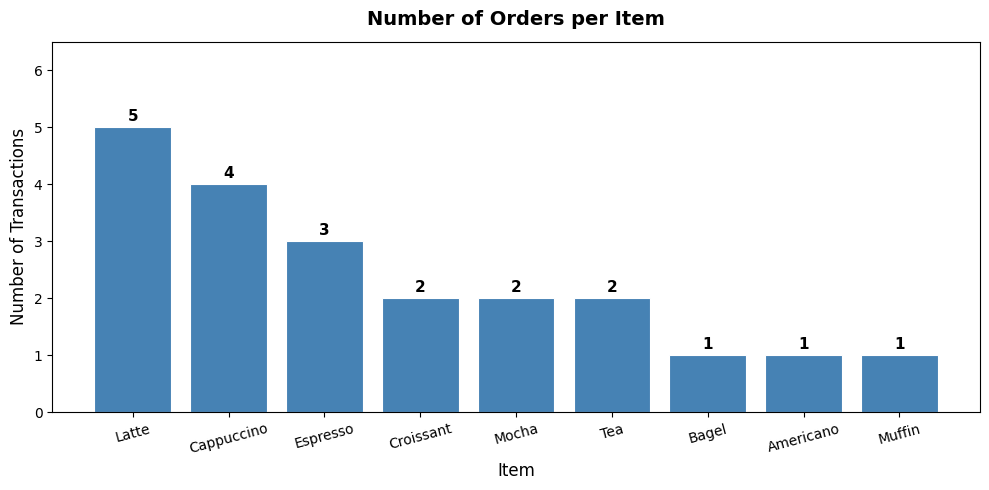

In [6]:
item_counts = df_2['Item'].value_counts()   # count rows per item
print('Order frequency per item:\n', item_counts)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(item_counts.index, item_counts.values,
              color='steelblue', edgecolor='white', linewidth=0.8)

# Label each bar with its count
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Number of Orders per Item', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Item', fontsize=12)
ax.set_ylabel('Number of Transactions', fontsize=12)
ax.set_ylim(0, item_counts.max() + 1.5)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

### 3️⃣ Total Revenue Generated by Each Item
> `groupby('Item')['TotalPrice'].sum()` — which item earns the most money?  
> The **highest bar is highlighted** in a darker blue so it stands out immediately.

Revenue by item:
 Item
Bagel          3.3
Muffin         3.3
Americano      3.6
Tea            5.4
Croissant      6.0
Espresso       9.9
Mocha         15.3
Cappuccino    25.2
Latte         33.6
Name: TotalPrice, dtype: float64


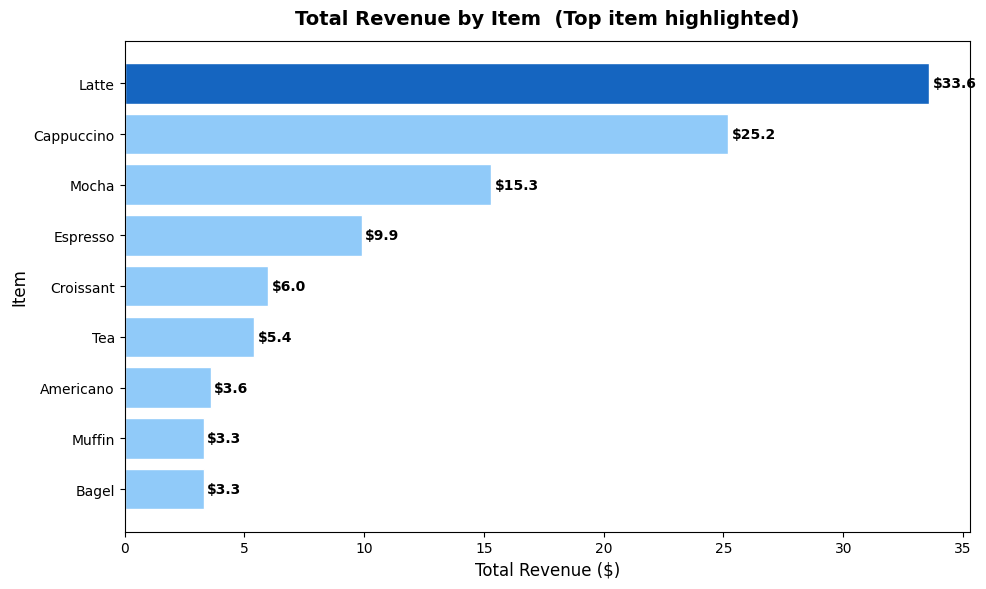

In [7]:
revenue_by_item = (
    df_2.groupby('Item')['TotalPrice']
        .sum()
        .sort_values(ascending=True)   # ascending so bars read top-to-bottom
)
print('Revenue by item:\n', revenue_by_item)

# Highlight the top earner
colors = ['#1565C0' if v == revenue_by_item.max() else '#90CAF9'
          for v in revenue_by_item.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(revenue_by_item.index, revenue_by_item.values,
               color=colors, edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 0.15,
            bar.get_y() + bar.get_height() / 2,
            f'${bar.get_width():.1f}',
            va='center', fontsize=10, fontweight='bold')

ax.set_title('Total Revenue by Item  (Top item highlighted)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Total Revenue ($)', fontsize=12)
ax.set_ylabel('Item', fontsize=12)
plt.tight_layout()
plt.show()

### 4️⃣ Payment Method — Transactions & Revenue
> Side-by-side view: **pie chart** shows share of transactions;  
> **bar chart** shows actual revenue per method.

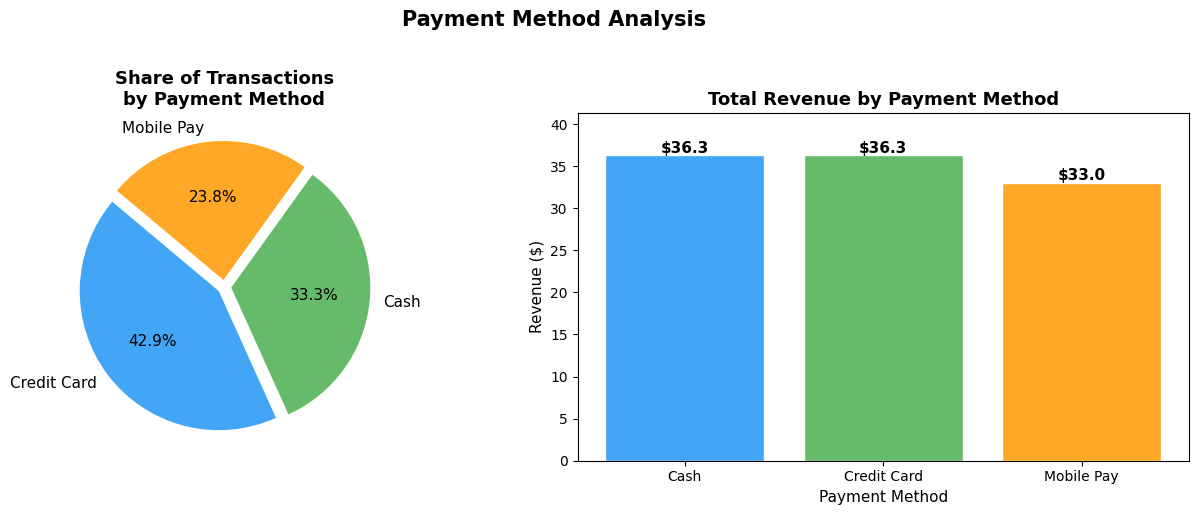

In [8]:
pay_count   = df_2['PaymentMethod'].value_counts()
pay_revenue = df_2.groupby('PaymentMethod')['TotalPrice'].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = ['#42A5F5', '#66BB6A', '#FFA726']

# ── Left: Pie chart ──────────────────────────────
axes[0].pie(
    pay_count.values,
    labels=pay_count.index,
    autopct='%1.1f%%',
    explode=[0.05] * len(pay_count),
    colors=palette,
    startangle=140,
    textprops={'fontsize': 11}
)
axes[0].set_title('Share of Transactions\nby Payment Method',
                  fontsize=13, fontweight='bold')

# ── Right: Bar chart — revenue ───────────────────
bars = axes[1].bar(pay_revenue.index, pay_revenue.values,
                   color=palette, edgecolor='white')
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'${bar.get_height():.1f}',
        ha='center', fontsize=11, fontweight='bold'
    )
axes[1].set_title('Total Revenue by Payment Method',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Payment Method', fontsize=11)
axes[1].set_ylabel('Revenue ($)', fontsize=11)
axes[1].set_ylim(0, pay_revenue.max() + 5)

plt.suptitle('Payment Method Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5️⃣ Daily Revenue Trend
> Extract the **date** from `DateTime` using `.dt.date`, then `groupby` + `sum`.  
> A line chart with an **area fill** shows revenue momentum over time.  
> The **peak day** is automatically annotated.

Daily Revenue:
       Date  Revenue
2025-09-01      9.6
2025-09-02      5.1
2025-09-03      3.0
2025-09-04      3.3
2025-09-05      4.8
2025-09-06     10.2
2025-09-08      4.2
2025-09-10      8.4
2025-09-11      4.8
2025-09-12      3.3
2025-09-13      8.4
2025-09-14      3.0
2025-09-15      2.7
2025-09-17      2.7
2025-09-18      3.3
2025-09-19      3.6
2025-09-20      4.2
2025-09-22      9.6
2025-09-23      3.3
2025-09-25      3.3
2025-09-26      4.8


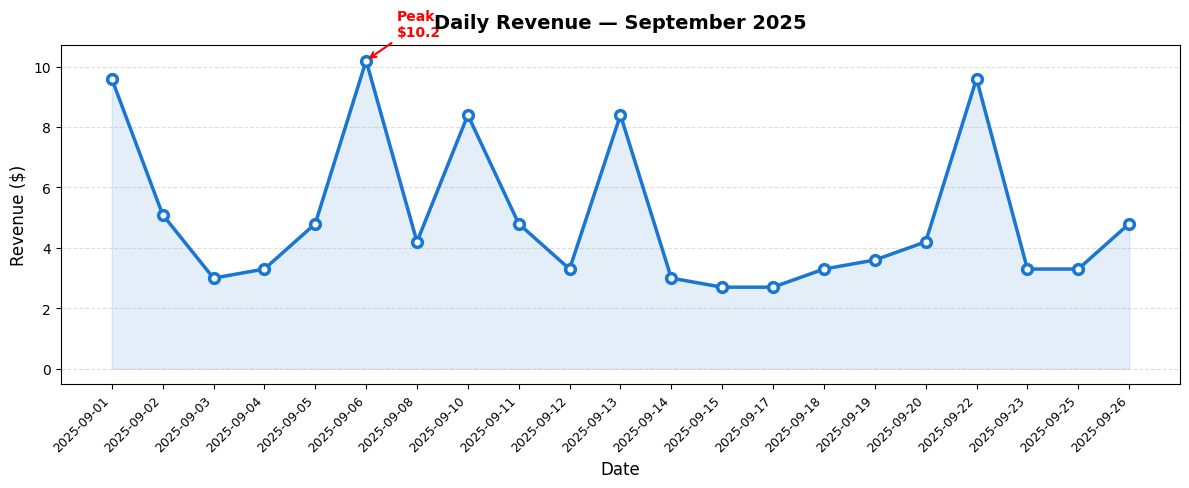

In [9]:
df_2['Date'] = df_2['DateTime'].dt.date          # extract just the date part
daily = df_2.groupby('Date')['TotalPrice'].sum().reset_index()
daily.columns = ['Date', 'Revenue']
print('Daily Revenue:\n', daily.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(daily))

ax.plot(x, daily['Revenue'], marker='o', color='#1976D2',
        linewidth=2.5, markersize=7,
        markerfacecolor='white', markeredgewidth=2.5)
ax.fill_between(x, daily['Revenue'], alpha=0.12, color='#1976D2')

# Annotate peak day
peak_idx = daily['Revenue'].idxmax()
ax.annotate(
    f"Peak\n${daily.loc[peak_idx,'Revenue']:.1f}",
    xy=(peak_idx, daily.loc[peak_idx, 'Revenue']),
    xytext=(peak_idx + 0.6, daily.loc[peak_idx, 'Revenue'] + 0.8),
    fontsize=10, color='red', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5)
)

ax.set_xticks(list(x))
ax.set_xticklabels([str(d) for d in daily['Date']],
                    rotation=45, ha='right', fontsize=9)
ax.set_title('Daily Revenue — September 2025',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Revenue ($)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 6️⃣ Hourly Sales Pattern — When Is the Shop Busiest?
> `.dt.hour` extracts the hour from `DateTime`.  
> Two subplots: **transaction count** per hour and **revenue** per hour side by side.

Hourly breakdown:
  Hour  Transactions  Revenue
    8             4     20.1
    9             4     15.9
   10             3     21.9
   11             3     16.2
   12             3     10.5
   13             3     16.2
   14             1      4.8


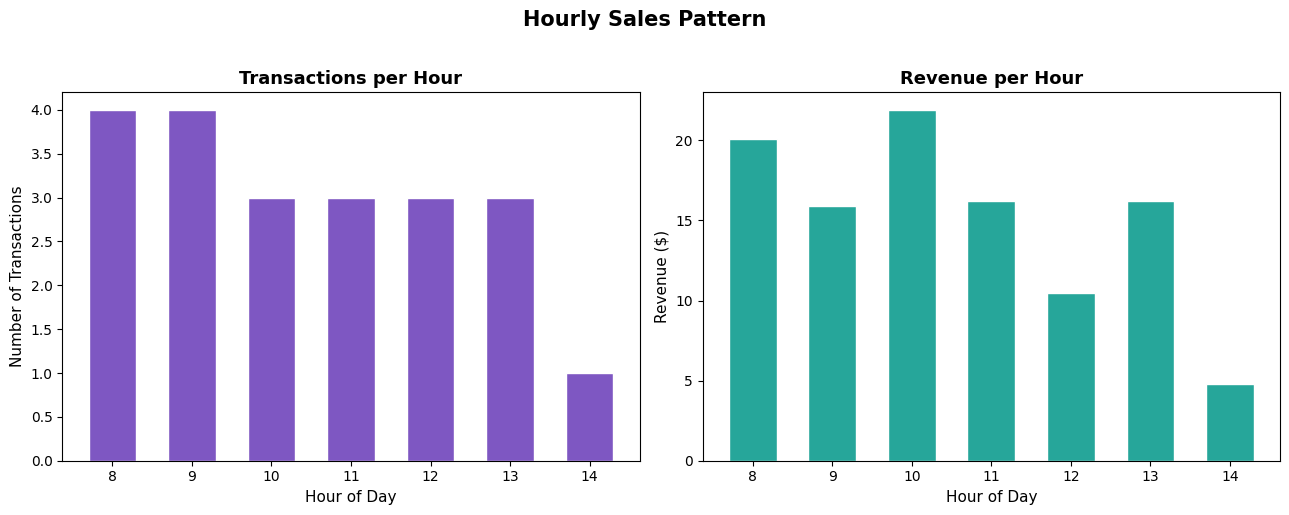

In [10]:
df_2['Hour'] = df_2['DateTime'].dt.hour    # extract hour (0-23)
hourly = df_2.groupby('Hour').agg(
    Transactions=('TransactionID', 'count'),
    Revenue=('TotalPrice', 'sum')
).reset_index()
print('Hourly breakdown:\n', hourly.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Transactions per hour ────────────────────────
axes[0].bar(hourly['Hour'], hourly['Transactions'],
            color='#7E57C2', edgecolor='white', width=0.6)
axes[0].set_title('Transactions per Hour', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day', fontsize=11)
axes[0].set_ylabel('Number of Transactions', fontsize=11)
axes[0].set_xticks(hourly['Hour'])

# ── Revenue per hour ─────────────────────────────
axes[1].bar(hourly['Hour'], hourly['Revenue'],
            color='#26A69A', edgecolor='white', width=0.6)
axes[1].set_title('Revenue per Hour', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour of Day', fontsize=11)
axes[1].set_ylabel('Revenue ($)', fontsize=11)
axes[1].set_xticks(hourly['Hour'])

plt.suptitle('Hourly Sales Pattern', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7️⃣ Distribution of Order Values
> **Histogram** (`plt.hist`) shows how order totals are spread — are most cheap or expensive?  
> `axvline` marks the **mean** and **median** so we can spot skew.  
> **Box plot** per item shows price spread and any outliers per product.

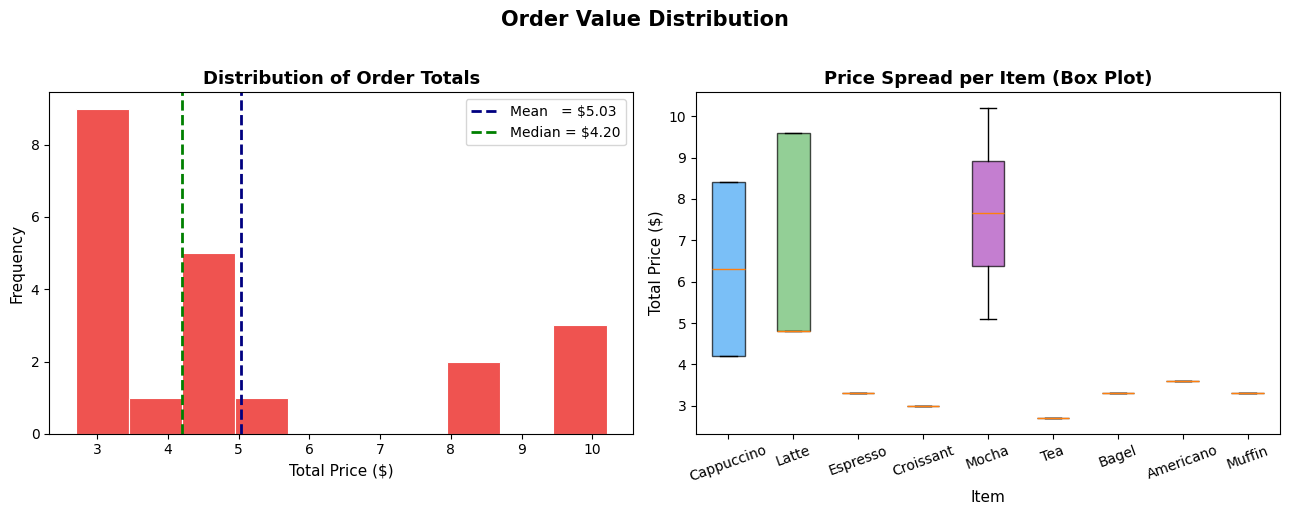

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Histogram of TotalPrice ────────────────
axes[0].hist(df_2['TotalPrice'], bins=10,
             color='#EF5350', edgecolor='white', linewidth=0.8)
axes[0].axvline(df_2['TotalPrice'].mean(), color='navy',
                linestyle='--', linewidth=2,
                label=f"Mean   = ${df_2['TotalPrice'].mean():.2f}")
axes[0].axvline(df_2['TotalPrice'].median(), color='green',
                linestyle='--', linewidth=2,
                label=f"Median = ${df_2['TotalPrice'].median():.2f}")
axes[0].set_title('Distribution of Order Totals',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Price ($)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend(fontsize=10)

# ── Right: Box plot — price spread per item ──────
items      = df_2['Item'].unique()
data_boxes = [df_2[df_2['Item'] == i]['TotalPrice'].values for i in items]
bp = axes[1].boxplot(data_boxes, labels=items, patch_artist=True)

box_colors = ['#42A5F5','#66BB6A','#FFA726','#EF5350',
              '#AB47BC','#26A69A','#EC407A','#7E57C2','#78909C']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Price Spread per Item (Box Plot)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Item', fontsize=11)
axes[1].set_ylabel('Total Price ($)', fontsize=11)
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Order Value Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8️⃣ Quantity Ordered per Item
> `groupby('Item').agg({'Quantity': ['sum','mean']})` — are customers buying multiples of any item?  
> Grouped bars compare **total units sold** vs **average units per transaction**.

Quantity per item:
             TotalQty  AvgQty
Item                        
Latte              7     1.4
Cappuccino         6     1.5
Mocha              3     1.5
Espresso           3     1.0
Tea                2     1.0
Croissant          2     1.0
Americano          1     1.0
Bagel              1     1.0
Muffin             1     1.0


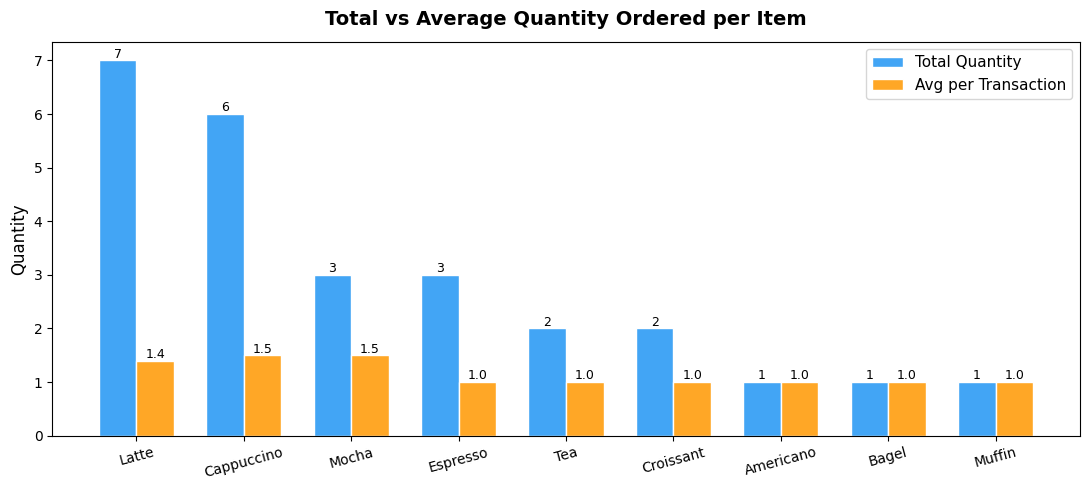

In [12]:
qty = (
    df_2.groupby('Item')['Quantity']
        .agg(TotalQty='sum', AvgQty='mean')
        .round(2)
        .sort_values('TotalQty', ascending=False)
)
print('Quantity per item:\n', qty)

x     = range(len(qty))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar([i - width/2 for i in x], qty['TotalQty'],
               width, label='Total Quantity', color='#42A5F5', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], qty['AvgQty'],
               width, label='Avg per Transaction', color='#FFA726', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.0f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(qty.index, rotation=15)
ax.set_title('Total vs Average Quantity Ordered per Item',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Quantity', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 9️⃣ Correlation Between Numeric Columns
> `.corr()` produces a matrix showing how strongly each pair of numeric columns  
> moves together (1 = perfect positive, -1 = perfect negative, 0 = no link).  
> `matshow` renders it as a colour grid — darker red = strong positive correlation.

Correlation Matrix:
               PricePerItem  Quantity  TotalPrice
PricePerItem          1.00      0.48        0.72
Quantity              0.48      1.00        0.95
TotalPrice            0.72      0.95        1.00


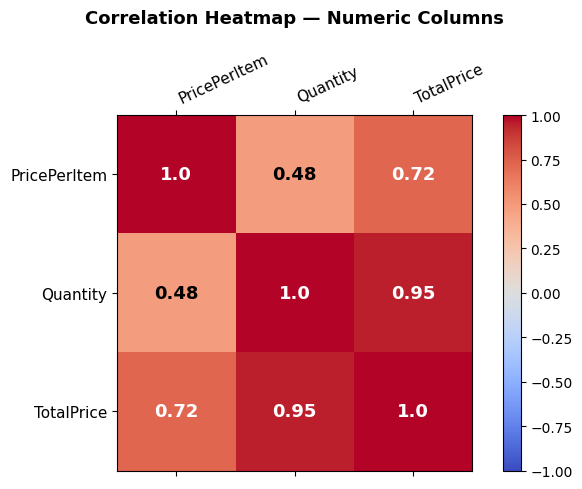

In [13]:
num_cols    = ['PricePerItem', 'Quantity', 'TotalPrice']
corr_matrix = df_2[num_cols].corr().round(2)
print('Correlation Matrix:\n', corr_matrix)

fig, ax = plt.subplots(figsize=(7, 5))
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(cax)

ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=25, ha='left', fontsize=11)
ax.set_yticklabels(num_cols, fontsize=11)

# Print correlation value inside each cell
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        val   = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=13, fontweight='bold', color=color)

ax.set_title('Correlation Heatmap — Numeric Columns',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 🔟 EDA Key Insights — Summary
> A final computed summary pulls together everything discovered above.  
> In a real data analytics project this would become the **executive summary** section.

In [14]:
rev_item  = df_2.groupby('Item')['TotalPrice'].sum().sort_values(ascending=False)
rev_pay   = df_2.groupby('PaymentMethod')['TotalPrice'].sum().sort_values(ascending=False)
busy_hour = df_2.groupby('Hour')['TransactionID'].count().idxmax()

print('=' * 58)
print('  ☕  COFFEE SHOP — EDA FINDINGS')
print('=' * 58)
print(f'  Total clean transactions  : {len(df_2)}')
print(f'  Date range               : '
      f'{df_2["DateTime"].min().date()} → {df_2["DateTime"].max().date()}')
print(f'  Total revenue            : ${df_2["TotalPrice"].sum():.2f}')
print(f'  Average order value      : ${df_2["TotalPrice"].mean():.2f}')
print()
print(f'  🥇 Best-selling item     : {rev_item.index[0]}')
print(f'     Revenue               : ${rev_item.iloc[0]:.2f}')
print()
print(f'  💳 Top payment method    : {rev_pay.index[0]}')
print(f'     Revenue               : ${rev_pay.iloc[0]:.2f}')
print()
print(f'  🕐 Busiest hour          : {busy_hour}:00')
print()
corr_qty   = df_2['Quantity'].corr(df_2['TotalPrice'])
corr_price = df_2['PricePerItem'].corr(df_2['TotalPrice'])
print(f'  📊 Qty   ↔ TotalPrice    : {corr_qty:.2f}  — strong positive ✅')
print(f'  📊 Price ↔ TotalPrice    : {corr_price:.2f}  — strong positive ✅')
print('=' * 58)

  ☕  COFFEE SHOP — EDA FINDINGS
  Total clean transactions  : 21
  Date range               : 2025-09-01 → 2025-09-26
  Total revenue            : $105.60
  Average order value      : $5.03

  🥇 Best-selling item     : Latte
     Revenue               : $33.60

  💳 Top payment method    : Cash
     Revenue               : $36.30

  🕐 Busiest hour          : 8:00

  📊 Qty   ↔ TotalPrice    : 0.95  — strong positive ✅
  📊 Price ↔ TotalPrice    : 0.72  — strong positive ✅


***

***